In [1]:
import os
import random
from itertools import product
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from aeon.classification.convolution_based import MiniRocketClassifier
from aeon.classification.sklearn import SklearnClassifierWrapper
from aeon.datasets.tsc_datasets import univariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from autotsc import utils

2025-11-18 16:00:17.620114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
write_dir = "experiments/automl_ca_vs_time_correlation"
os.makedirs(write_dir, exist_ok=True)

datasets = list(univariate)
random.shuffle(datasets)
model_types = [
    "raw-scale-ridge",
    "quant",
    "minirocket",
    "catch22",
    "hydra",
    "tabpfn",
]  # , "shapelet"]

n_jobs = 4
n_runs = 5

In [3]:
def get_model(model_name):
    from aeon.classification.convolution_based import HydraClassifier
    from aeon.classification.feature_based import Catch22Classifier
    from aeon.classification.interval_based import QUANTClassifier
    from aeon.classification.shapelet_based import ShapeletTransformClassifier
    from tabpfn import TabPFNClassifier

    if model_name == "raw-scale-ridge":
        return SklearnClassifierWrapper(
            make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)))
        )
    elif model_name == "tabpfn":
        return SklearnClassifierWrapper(TabPFNClassifier(n_preprocessing_jobs=n_jobs))
    elif model_name == "quant":
        return QUANTClassifier()
    elif model_name == "minirocket":
        return MiniRocketClassifier(n_jobs=n_jobs)
    elif model_name == "catch22":
        return Catch22Classifier(n_jobs=n_jobs)
    elif model_name == "hydra":
        return HydraClassifier(n_jobs=n_jobs)
    elif model_name == "shapelet":
        return ShapeletTransformClassifier(n_jobs=n_jobs)
    else:
        raise ValueError(f"Unknown model: {model_name}")

In [ ]:
all_combinations = list(product(datasets, range(n_runs), model_types))

last_dataset = None
X_train, y_train, X_test, y_test = None, None, None, None

for ds, run, model_name in tqdm(all_combinations, desc="Processing"):
    try:
        model = get_model(model_name)
        stats = {
            "dataset": ds,
            "run": run,
            "model": model_name,
        }

        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file = f"{write_dir}/{hash_val}.parquet"

        if os.path.exists(file):
            continue
        else:
            print(f"Processing {stats}")

        if ds != last_dataset:
            X_train, y_train, X_test, y_test = utils.load_dataset(ds)
            last_dataset = ds

        start_time = perf_counter()
        model.fit(X_train, y_train)
        training_time = perf_counter() - start_time
        y_pred = model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)

        stats["test_accuracy"] = test_accuracy
        stats["training_time"] = training_time

        df_stat = pl.DataFrame([stats])
        df_stat.write_parquet(file)

    except Exception as e:
        print(f"Error processing {ds}, run {run}, model {model_name}: {e}")
        continue

Processing:   0%|          | 6/3840 [00:00<08:52,  7.19it/s]

Processing {'dataset': 'CricketY', 'run': 0, 'model': 'tabpfn'}


Processing:   3%|▎         | 126/3840 [00:01<00:25, 147.32it/s]

Error processing CricketY, run 0, model tabpfn: Number of classes 12 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'CricketY', 'run': 1, 'model': 'tabpfn'}
Error processing CricketY, run 1, model tabpfn: Number of classes 12 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'CricketY', 'run': 2, 'model': 'tabpfn'}
Error processing CricketY, run 2, model tabpfn: Number of classes 12 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extens

Processing:   6%|▋         | 241/3840 [00:01<00:14, 244.61it/s]

...

Error processing Adiac, run 0, model tabpfn: Number of classes 37 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'Adiac', 'run': 1, 'model': 'tabpfn'}
Error processing Adiac, run 1, model tabpfn: Number of classes 37 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'Adiac', 'run': 2, 'model': 'tabpfn'}
Error processing Adiac, run 2, model tabpfn: Number of classes 37 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/

Processing:  89%|████████▉ | 3418/3840 [00:29<00:02, 205.10it/s]

Error processing Adiac, run 3, model tabpfn: Number of classes 37 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'Adiac', 'run': 4, 'model': 'tabpfn'}
Error processing Adiac, run 4, model tabpfn: Number of classes 37 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'Crop', 'run': 0, 'model': 'tabpfn'}
Error processing Crop, run 0, model tabpfn: Number of classes 24 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/sr

Processing: 100%|██████████| 3840/3840 [00:29<00:00, 128.66it/s]

Error processing Crop, run 3, model tabpfn: Number of classes 24 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py
Processing {'dataset': 'Crop', 'run': 4, 'model': 'tabpfn'}
Error processing Crop, run 4, model tabpfn: Number of classes 24 exceeds the maximal number of classes supported by TabPFN. Consider using a strategy to reduce the number of classes. For code see https://github.com/PriorLabs/tabpfn-extensions/blob/main/src/tabpfn_extensions/many_class/many_class_classifier.py


In [5]:
df = pl.read_parquet(f"{write_dir}/*.parquet").filter(pl.col("dataset").is_in(datasets))
df

dataset,run,model,test_accuracy,training_time
str,i64,str,f64,f64
"""GestureMidAirD3""",0,"""hydra""",0.492308,0.636526
"""CBF""",0,"""raw-scale-ridge""",0.831111,0.002589
"""RefrigerationDevices""",4,"""hydra""",0.517333,2.367889
"""SemgHandSubjectCh2""",4,"""quant""",0.895556,5.385477
"""Wafer""",3,"""tabpfn""",0.994646,0.19906
…,…,…,…,…
"""CricketX""",3,"""quant""",0.728205,1.746649
"""ElectricDevices""",4,"""tabpfn""",0.715342,0.457792
"""FaceFour""",1,"""tabpfn""",0.931818,0.138533


In [6]:
datasets

['SonyAIBORobotSurface1',
 'StarLightCurves',
 'Car',
 'OSULeaf',
 'CricketY',
 'Beef',
 'Ham',
 'DodgerLoopGame',
 'ShapesAll',
 'FreezerRegularTrain',
 'TwoPatterns',
 'EthanolLevel',
 'GestureMidAirD3',
 'WordSynonyms',
 'GestureMidAirD2',
 'ShapeletSim',
 'AllGestureWiimoteY',
 'ItalyPowerDemand',
 'InlineSkate',
 'Haptics',
 'Lightning7',
 'FaceFour',
 'BeetleFly',
 'HouseTwenty',
 'FordB',
 'UWaveGestureLibraryX',
 'NonInvasiveFetalECGThorax1',
 'SyntheticControl',
 'CricketX',
 'BirdChicken',
 'GesturePebbleZ1',
 'Worms',
 'SmoothSubspace',
 'UWaveGestureLibraryAll',
 'CricketZ',
 'EOGHorizontalSignal',
 'MelbournePedestrian',
 'Fungi',
 'Trace',
 'Rock',
 'MixedShapesSmallTrain',
 'CinCECGTorso',
 'PhalangesOutlinesCorrect',
 'Mallat',
 'ShakeGestureWiimoteZ',
 'PickupGestureWiimoteZ',
 'PLAID',
 'ToeSegmentation1',
 'GesturePebbleZ2',
 'LargeKitchenAppliances',
 'Meat',
 'ArrowHead',
 'PigAirwayPressure',
 'SwedishLeaf',
 'AllGestureWiimoteX',
 'SmallKitchenAppliances',
 'UWav

In [7]:
gdf = df.group_by("dataset", "model").agg([pl.col("test_accuracy").mean()]).sort("test_accuracy")

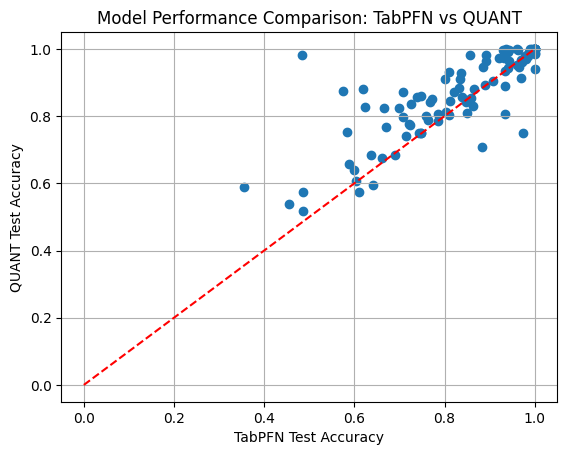

In [8]:
together_dataset = set(gdf.filter(pl.col("model") == "tabpfn")["dataset"]).intersection(
    set(gdf.filter(pl.col("model") == "quant")["dataset"])
)
v1 = (
    gdf.filter(pl.col("model") == "tabpfn")
    .filter(pl.col("dataset").is_in(together_dataset))
    .sort("dataset")["test_accuracy"]
)
v2 = (
    gdf.filter(pl.col("model") == "quant")
    .filter(pl.col("dataset").is_in(together_dataset))
    .sort("dataset")["test_accuracy"]
)
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("TabPFN Test Accuracy")
plt.ylabel("QUANT Test Accuracy")
plt.title("Model Performance Comparison: TabPFN vs QUANT")
plt.grid(True)
plt.show()

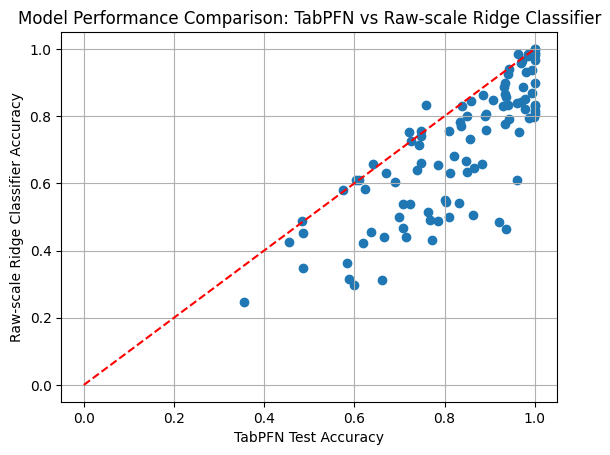

In [9]:
together_dataset = set(gdf.filter(pl.col("model") == "tabpfn")["dataset"]).intersection(
    set(gdf.filter(pl.col("model") == "raw-scale-ridge")["dataset"])
)
v1 = (
    gdf.filter(pl.col("model") == "tabpfn")
    .filter(pl.col("dataset").is_in(together_dataset))
    .sort("dataset")["test_accuracy"]
)
v2 = (
    gdf.filter(pl.col("model") == "raw-scale-ridge")
    .filter(pl.col("dataset").is_in(together_dataset))
    .sort("dataset")["test_accuracy"]
)
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("TabPFN Test Accuracy")
plt.ylabel("Raw-scale Ridge Classifier Accuracy")
plt.title("Model Performance Comparison: TabPFN vs Raw-scale Ridge Classifier")
plt.grid(True)
plt.show()

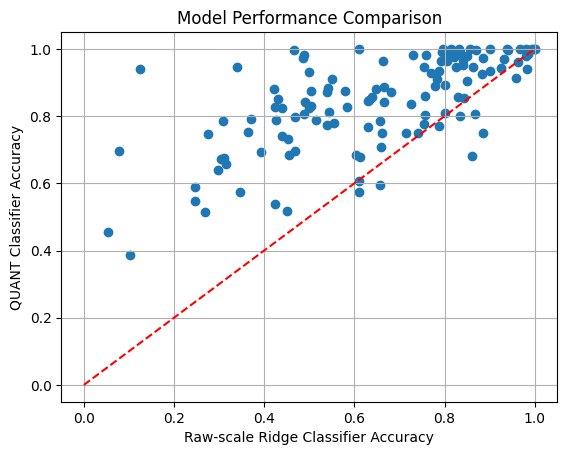

In [10]:
v1 = gdf.filter(pl.col("model") == "raw-scale-ridge").sort("dataset")["test_accuracy"]
v2 = gdf.filter(pl.col("model") == "quant").sort("dataset")["test_accuracy"]
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("Raw-scale Ridge Classifier Accuracy")
plt.ylabel("QUANT Classifier Accuracy")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.show()

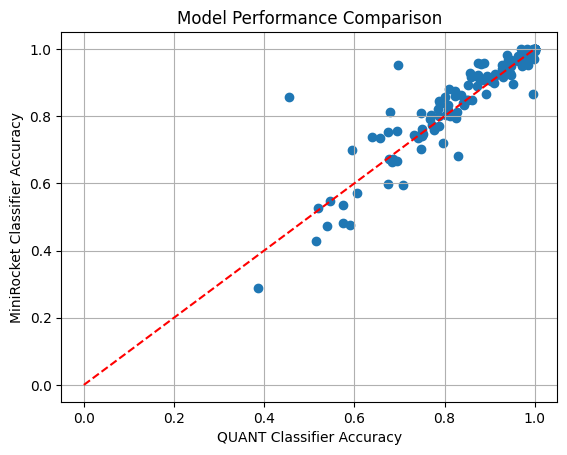

In [11]:
v1 = gdf.filter(pl.col("model") == "quant").sort("dataset")["test_accuracy"]
v2 = gdf.filter(pl.col("model") == "minirocket").sort("dataset")["test_accuracy"]
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("QUANT Classifier Accuracy")
plt.ylabel("MiniRocket Classifier Accuracy")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.show()

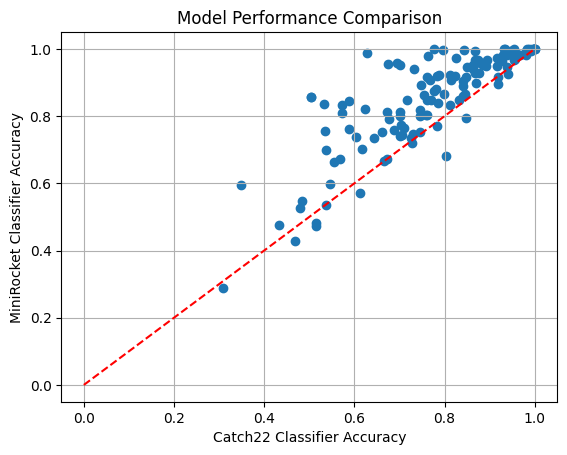

In [12]:
v1 = gdf.filter(pl.col("model") == "catch22").sort("dataset")["test_accuracy"]
v2 = gdf.filter(pl.col("model") == "minirocket").sort("dataset")["test_accuracy"]
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("Catch22 Classifier Accuracy")
plt.ylabel("MiniRocket Classifier Accuracy")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.show()

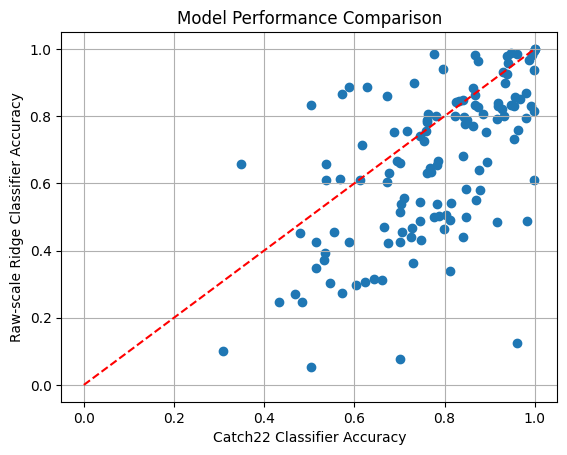

In [13]:
v1 = gdf.filter(pl.col("model") == "catch22").sort("dataset")["test_accuracy"]
v2 = gdf.filter(pl.col("model") == "raw-scale-ridge").sort("dataset")["test_accuracy"]
plt.scatter(v1, v2)
# plot read line y=x
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("Catch22 Classifier Accuracy")
plt.ylabel("Raw-scale Ridge Classifier Accuracy")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.show()

In [14]:
gdf = df.group_by("dataset", "model").agg([pl.col("training_time").mean()]).sort("dataset", "model")

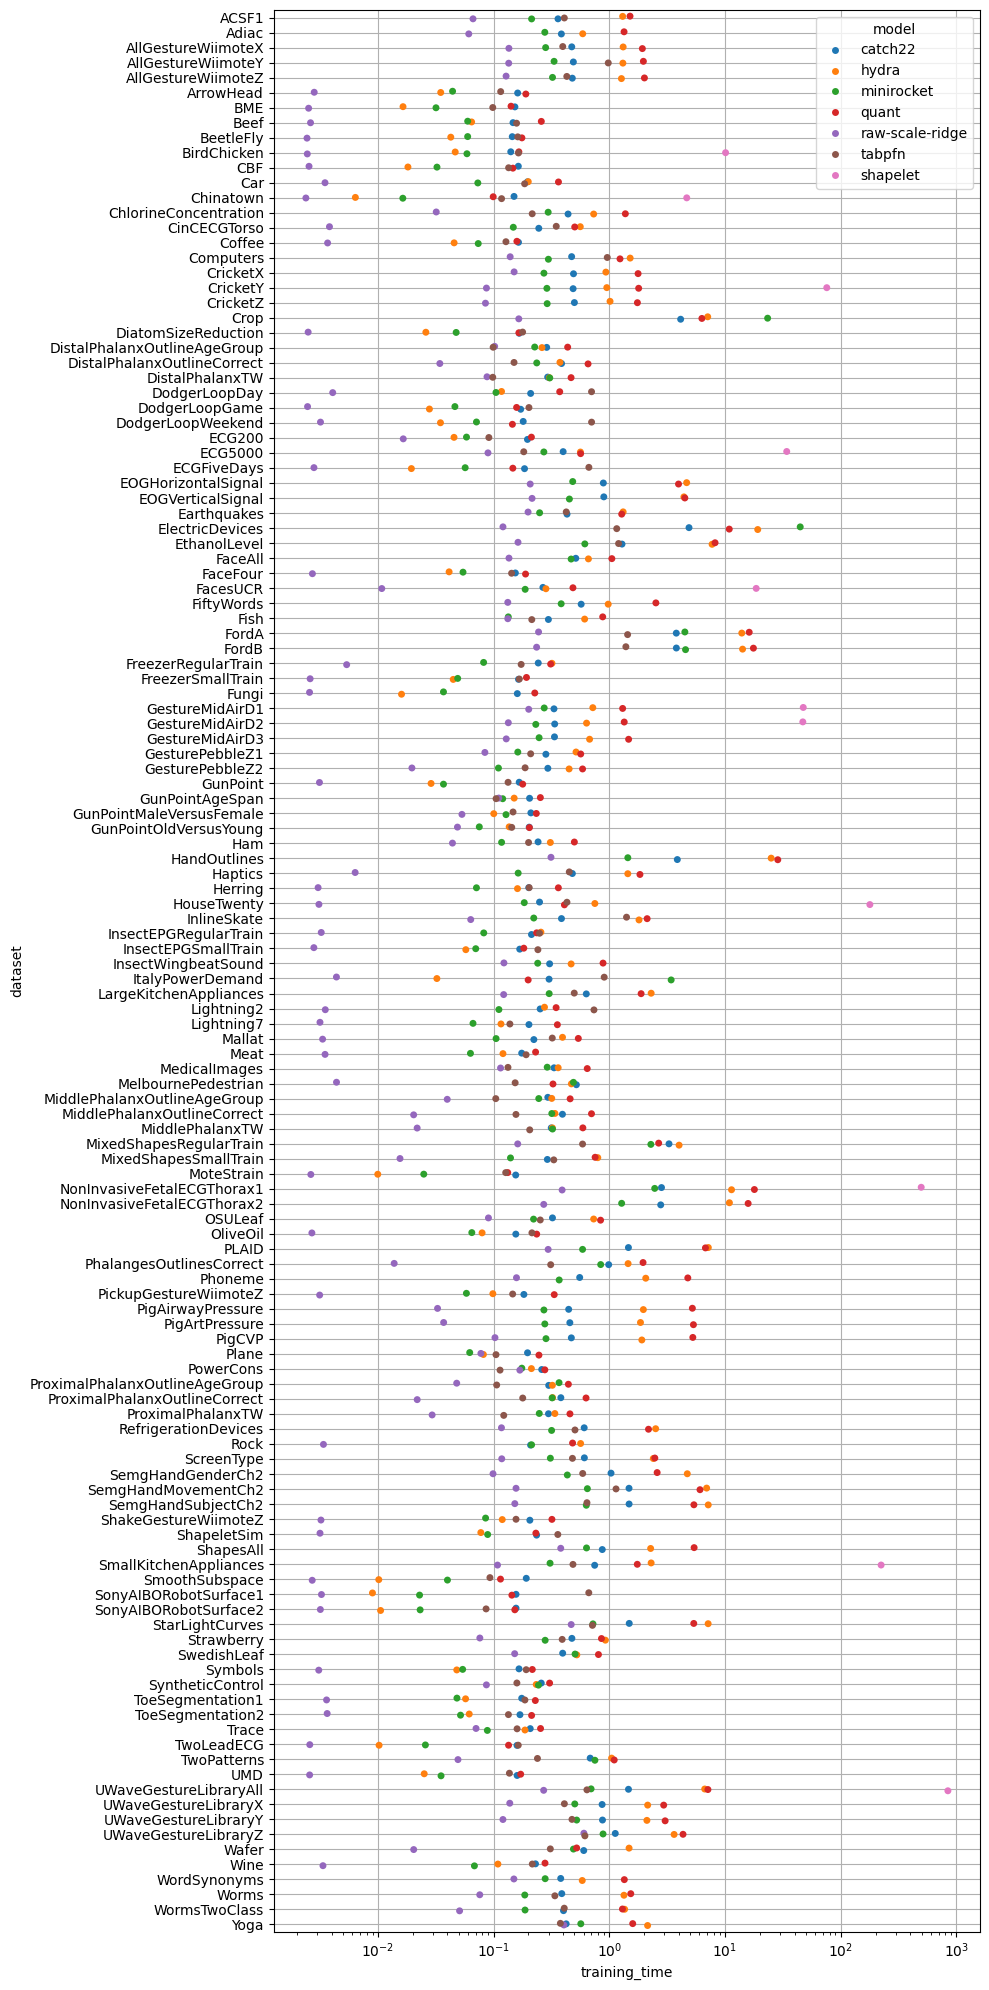

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 20))
sns.stripplot(data=gdf, y="dataset", x="training_time", hue="model", dodge=False)
plt.grid(True)
plt.xscale("log")
plt.tight_layout()
plt.show()

In [16]:
gdf = df.group_by("dataset", "model").agg([pl.col("test_accuracy").mean()]).sort("dataset", "model")

In [17]:
df["dataset"].unique()

dataset
str
"""Haptics"""
"""PhalangesOutlinesCorrect"""
"""InsectEPGRegularTrain"""
"""WordSynonyms"""
"""PickupGestureWiimoteZ"""
…
"""NonInvasiveFetalECGThorax1"""
"""DodgerLoopWeekend"""
"""StarLightCurves"""


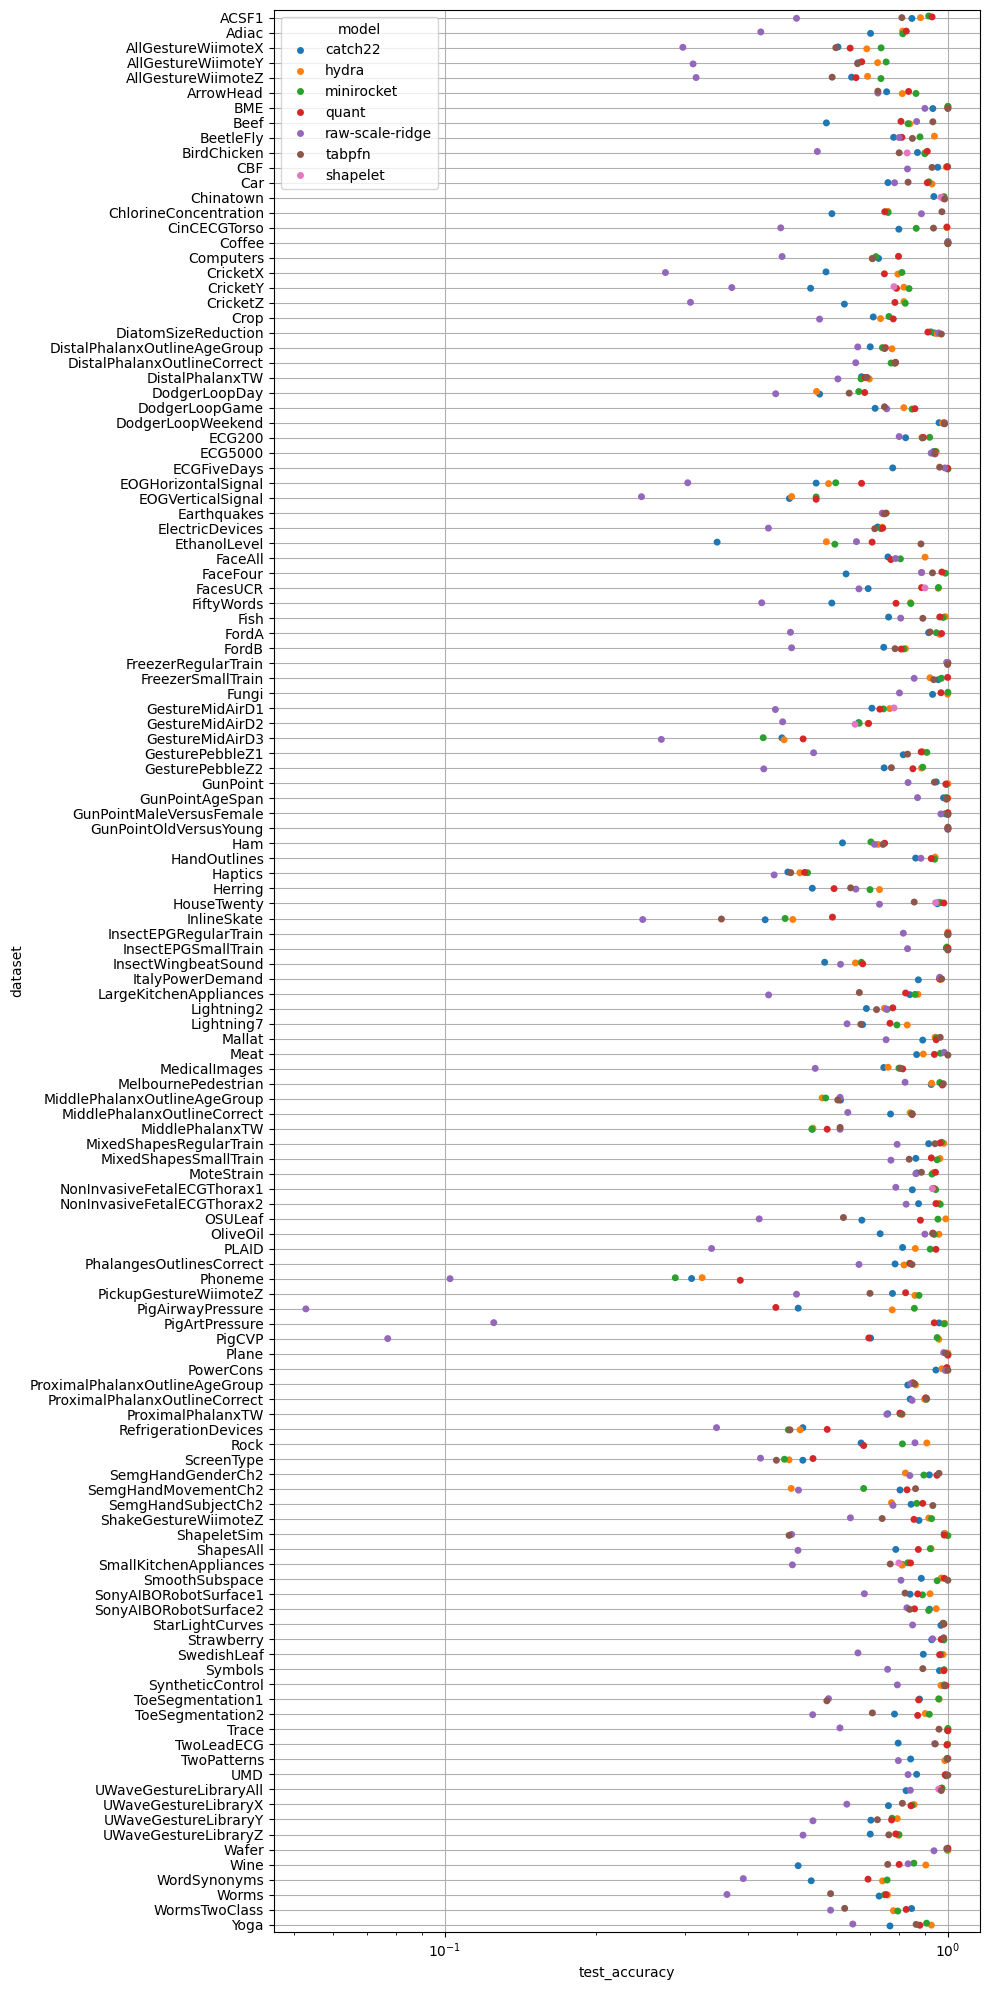

In [18]:
import seaborn as sns

plt.figure(figsize=(10, 20))
sns.stripplot(data=gdf, y="dataset", x="test_accuracy", hue="model", dodge=False)
plt.grid(True)
plt.xscale("log")
plt.tight_layout()
plt.show()

In [19]:
gdf = (
    df.group_by("dataset", "model")
    .agg([pl.col("test_accuracy").mean(), pl.col("training_time").mean()])
    .sort("dataset", "model")
)

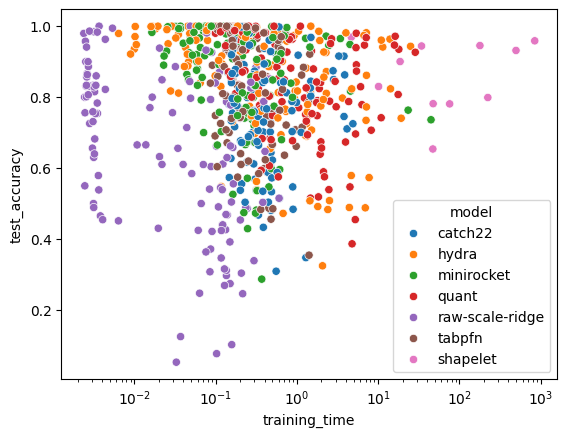

In [20]:
sns.scatterplot(data=gdf, x="training_time", y="test_accuracy", hue="model")
plt.xscale("log")